# COMP-2704: Supervised Machine Learning Term 
## Data Analysis and Preparation 
## 1) Problem and Use Case Definition
Several external and internal factors we face every day can affect our mental health condition either in a positive or a negative way. Despite our ability to tell what is good for our mental health apart from what is not, being aware of every single aspect and its consequences is not an easy task.

In this use case, we are going to leverage machine learning capabilities to identify positive and negative aspects of our lifes in detail, demonstrating how data science can enhance medical diagnosis by developing a classification model. The goal is to enable earlier detection and provide employees with timely and relevant treatments.

**Target Variable**: Mental_Health_Condition
- Class 0 (N): No mental health condition (52.4% of dataset)
- Class 1 (Y): Has mental health condition (47.6% of dataset)

**Objective**: Develop a supervised machine learning model to predict whether an individual has a mental health condition (Yes/No) based on demographic, lifestyle, and behavioral features.

### Dataset Description
The dataset is `mental_health_dataset`. This dataset comprises 50,000 records capturing various mental health and lifestyle factors. These factors are represented as the feature columns of the data set, which fall into the following categories:
- **Demographic:** This includes each person demographic information such as age, gender, occupation and country.
- **Mental Health Indicators:** This includes features like the stress level, consultation history and medication usage.
- **Lifestyle:** This includes information complementary information such as sleep hours, work hours, physical activity, social media usage and diet quality.
- **Additional Details:** This includes information about external factors such as smoking and alcohol consumption habits categorized into multiple levels.
### Classification Model Considerations.
**Problem Type**: Binary Classification

**Evaluation Focus**: We prioritize sensitivity (recall) to minimize false negatives, 
as failing to identify individuals with mental health conditions has serious consequences.



## 2) Clean the data
### Missing values and Duplicates

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

# Defining global variables
LABEL = 'Mental_Health_Condition'

In [2]:
df = pd.read_csv('data/mental_health_data final data.csv')
df.head()

,User_ID,Age,Gender,Occupation,Country,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage
0,1,36,Male,Education,Australia,Yes,NaN,Yes,Low,7.6,46,8,2.2,Healthy,Regular Smoker,Regular Drinker,Yes
1,2,48,Male,Engineering,Other,No,Low,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No
2,3,18,Prefer not to say,Sales,India,No,NaN,Yes,Medium,7.1,77,9,5.9,Healthy,Heavy Smoker,Social Drinker,No
3,4,30,Non-binary,Engineering,Australia,No,Medium,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No
4,5,58,Male,IT,USA,Yes,NaN,Yes,High,4.7,45,10,3.3,Unhealthy,Regular Smoker,Non-Drinker,Yes


Getting information about our dataset:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  50000 non-null  int64  
 1   Age                      50000 non-null  int64  
 2   Gender                   50000 non-null  object 
 3   Occupation               50000 non-null  object 
 4   Country                  50000 non-null  object 
 5   Mental_Health_Condition  50000 non-null  object 
 6   Severity                 24998 non-null  object 
 7   Consultation_History     50000 non-null  object 
 8   Stress_Level             50000 non-null  object 
 9   Sleep_Hours              50000 non-null  float64
 10  Work_Hours               50000 non-null  int64  
 11  Physical_Activity_Hours  50000 non-null  int64  
 12  Social_Media_Usage       50000 non-null  float64
 13  Diet_Quality             50000 non-null  object 
 14  Smoking_Habit         

As we can see, the only column that has null values is the severity column, let;s try to understand why:

In [4]:
print(df['Severity'].value_counts())
print(df['Severity'].isnull().sum())

Severity
Medium    8436
High      8301
Low       8261
Name: count, dtype: int64
25002


In [5]:
df[df['Severity'].isnull()][['Mental_Health_Condition','Severity']]

,Mental_Health_Condition,Severity
0,Yes,NaN
2,No,NaN
4,Yes,NaN
7,Yes,NaN
10,Yes,NaN
...,...,...
49985,No,NaN
49988,No,NaN
49990,No,NaN
49992,No,NaN


As a conclusion, we can see that there is missing information about the severity of the mental health condition (if the individual has one) for almost half the number of rows we have in our dataset.This column will be dropped as we are going to analyze only if the individual has or doesn't have a mental health condition based on the features.

In [6]:
# Dropping Severity column
df = df.drop(columns=['Severity'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  50000 non-null  int64  
 1   Age                      50000 non-null  int64  
 2   Gender                   50000 non-null  object 
 3   Occupation               50000 non-null  object 
 4   Country                  50000 non-null  object 
 5   Mental_Health_Condition  50000 non-null  object 
 6   Consultation_History     50000 non-null  object 
 7   Stress_Level             50000 non-null  object 
 8   Sleep_Hours              50000 non-null  float64
 9   Work_Hours               50000 non-null  int64  
 10  Physical_Activity_Hours  50000 non-null  int64  
 11  Social_Media_Usage       50000 non-null  float64
 12  Diet_Quality             50000 non-null  object 
 13  Smoking_Habit            50000 non-null  object 
 14  Alcohol_Consumption   

In [7]:
# Transforming target variable to 'Y' and 'N'
df['Mental_Health_Condition'] = df[LABEL].map({'Yes': 'Y', 'No': 'N'})
df.head()

,User_ID,Age,Gender,Occupation,Country,Mental_Health_Condition,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage
0,1,36,Male,Education,Australia,Y,Yes,Low,7.6,46,8,2.2,Healthy,Regular Smoker,Regular Drinker,Yes
1,2,48,Male,Engineering,Other,N,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No
2,3,18,Prefer not to say,Sales,India,N,Yes,Medium,7.1,77,9,5.9,Healthy,Heavy Smoker,Social Drinker,No
3,4,30,Non-binary,Engineering,Australia,N,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No
4,5,58,Male,IT,USA,Y,Yes,High,4.7,45,10,3.3,Unhealthy,Regular Smoker,Non-Drinker,Yes


### Checking duplicates

In [8]:
any(df.duplicated())

False

No duplicates on the data!

As part of our analysis, we'd also like to get rid of the columns that don't really contribute to our prediction, those are determined to be `User_ID` and `Country` as the model won't use this information for predicting the mental health condition.

In [9]:
df.drop(columns=['User_ID', 'Country'], inplace=True)

I'm going to consider splitting the ages column into several groups as this may lead to capture possible non-linear relationships.

In [10]:
splitter_dict = {'18_25':[18,25],
                 '26_35':[26,35],
                 '36_45':[36,45],
                 '46_55':[46,55],
                 '56+':[56,100]}

age_classifier = lambda row : [k for k,(low , high) in splitter_dict.items() 
                               if low <= row['Age'] <= high]
df['Age_Group'] = df.apply(age_classifier, axis=1).str[0]
df.drop(columns=['Age'], inplace = True)
df.head()

,Gender,Occupation,Mental_Health_Condition,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage,Age_Group
0,Male,Education,Y,Yes,Low,7.6,46,8,2.2,Healthy,Regular Smoker,Regular Drinker,Yes,36_45
1,Male,Engineering,N,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No,46_55
2,Prefer not to say,Sales,N,Yes,Medium,7.1,77,9,5.9,Healthy,Heavy Smoker,Social Drinker,No,18_25
3,Non-binary,Engineering,N,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No,26_35
4,Male,IT,Y,Yes,High,4.7,45,10,3.3,Unhealthy,Regular Smoker,Non-Drinker,Yes,56+


In [11]:
print(f"\n Data Range Validation:")
print(f"   - Sleep hours range: {df['Sleep_Hours'].min():.1f}-{df['Sleep_Hours'].max():.1f} (expect 0-24)")
print(f"   - Work hours range: {df['Work_Hours'].min()}-{df['Work_Hours'].max()} (reasonable?)")



 Data Range Validation:
   - Sleep hours range: 4.0-10.0 (expect 0-24)
   - Work hours range: 30-80 (reasonable?)


## 3) Describing my data

Checking label distribution to ensure labels are balanced in my dataset.

In [12]:
print(df['Mental_Health_Condition'].value_counts(normalize=True))

Mental_Health_Condition
N    0.50006
Y    0.49994
Name: proportion, dtype: float64


In [13]:
print('Showing descriptive statistics for individuals with no mental health condition (N):')
df.describe(include = 'number')

Showing descriptive statistics for individuals with no mental health condition (N):


,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,7.009934,55.062860,4.982040,3.243160
std,1.732674,14.691575,3.161759,1.585235
min,4.000000,30.000000,0.000000,0.500000
25%,5.500000,42.000000,2.000000,1.900000
50%,7.000000,55.000000,5.000000,3.200000
75%,8.500000,68.000000,8.000000,4.600000
max,10.000000,80.000000,10.000000,6.000000


Showing the numerical data fields distribution in a table.

In [14]:
# Printing countvalues for each column
columns_to_analyze = df.select_dtypes(exclude='number').columns

for column in columns_to_analyze:
    print(f'Value counts for {column}:\n{df[column].value_counts()}\n')

Value counts for Gender:
Gender
Female               12633
Prefer not to say    12558
Male                 12473
Non-binary           12336
Name: count, dtype: int64

Value counts for Occupation:
Occupation
Finance        7286
IT             7281
Other          7112
Healthcare     7105
Education      7089
Engineering    7072
Sales          7055
Name: count, dtype: int64

Value counts for Mental_Health_Condition:
Mental_Health_Condition
N    25003
Y    24997
Name: count, dtype: int64

Value counts for Consultation_History:
Consultation_History
No     25110
Yes    24890
Name: count, dtype: int64

Value counts for Stress_Level:
Stress_Level
Medium    16847
High      16707
Low       16446
Name: count, dtype: int64

Value counts for Diet_Quality:
Diet_Quality
Unhealthy    16729
Healthy      16638
Average      16633
Name: count, dtype: int64

Value counts for Smoking_Habit:
Smoking_Habit
Non-Smoker           12580
Occasional Smoker    12556
Regular Smoker       12438
Heavy Smoker         124

Showing value counts per categorical fields (Nominal and Ordinal).
This step is also going to be supported by visualizations in the next section!

### Pearson Coefficient for correlation between numerical data and the target variable


In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_corr = df.copy() # Creating a copy of df to avoid modifying the original dataframe
df_corr['Mental_Health_Condition_Encoded'] = df_corr[LABEL].map({'Y': 1, 'N': 0}) # Encoding target variable for correlation calculation

corr_matrix = df_corr[numeric_cols.tolist()  + 
                       ['Mental_Health_Condition_Encoded']].corr()['Mental_Health_Condition_Encoded'].drop('Mental_Health_Condition_Encoded')
corr_matrix_sorted = corr_matrix.abs().sort_values(ascending=False)
for feature, corr_value in corr_matrix_sorted.items():
    print(f"{feature:30s}: {corr_value:.4f}")


Physical_Activity_Hours       : 0.0058
Sleep_Hours                   : 0.0005
Work_Hours                    : 0.0003
Social_Media_Usage            : 0.0003


This is the dataset we are going to work with.

## 4) Creating Visualizations

In this step, we are going to use visualization to both understand the data and present it. This will help to validate consistency on the dataset as well.

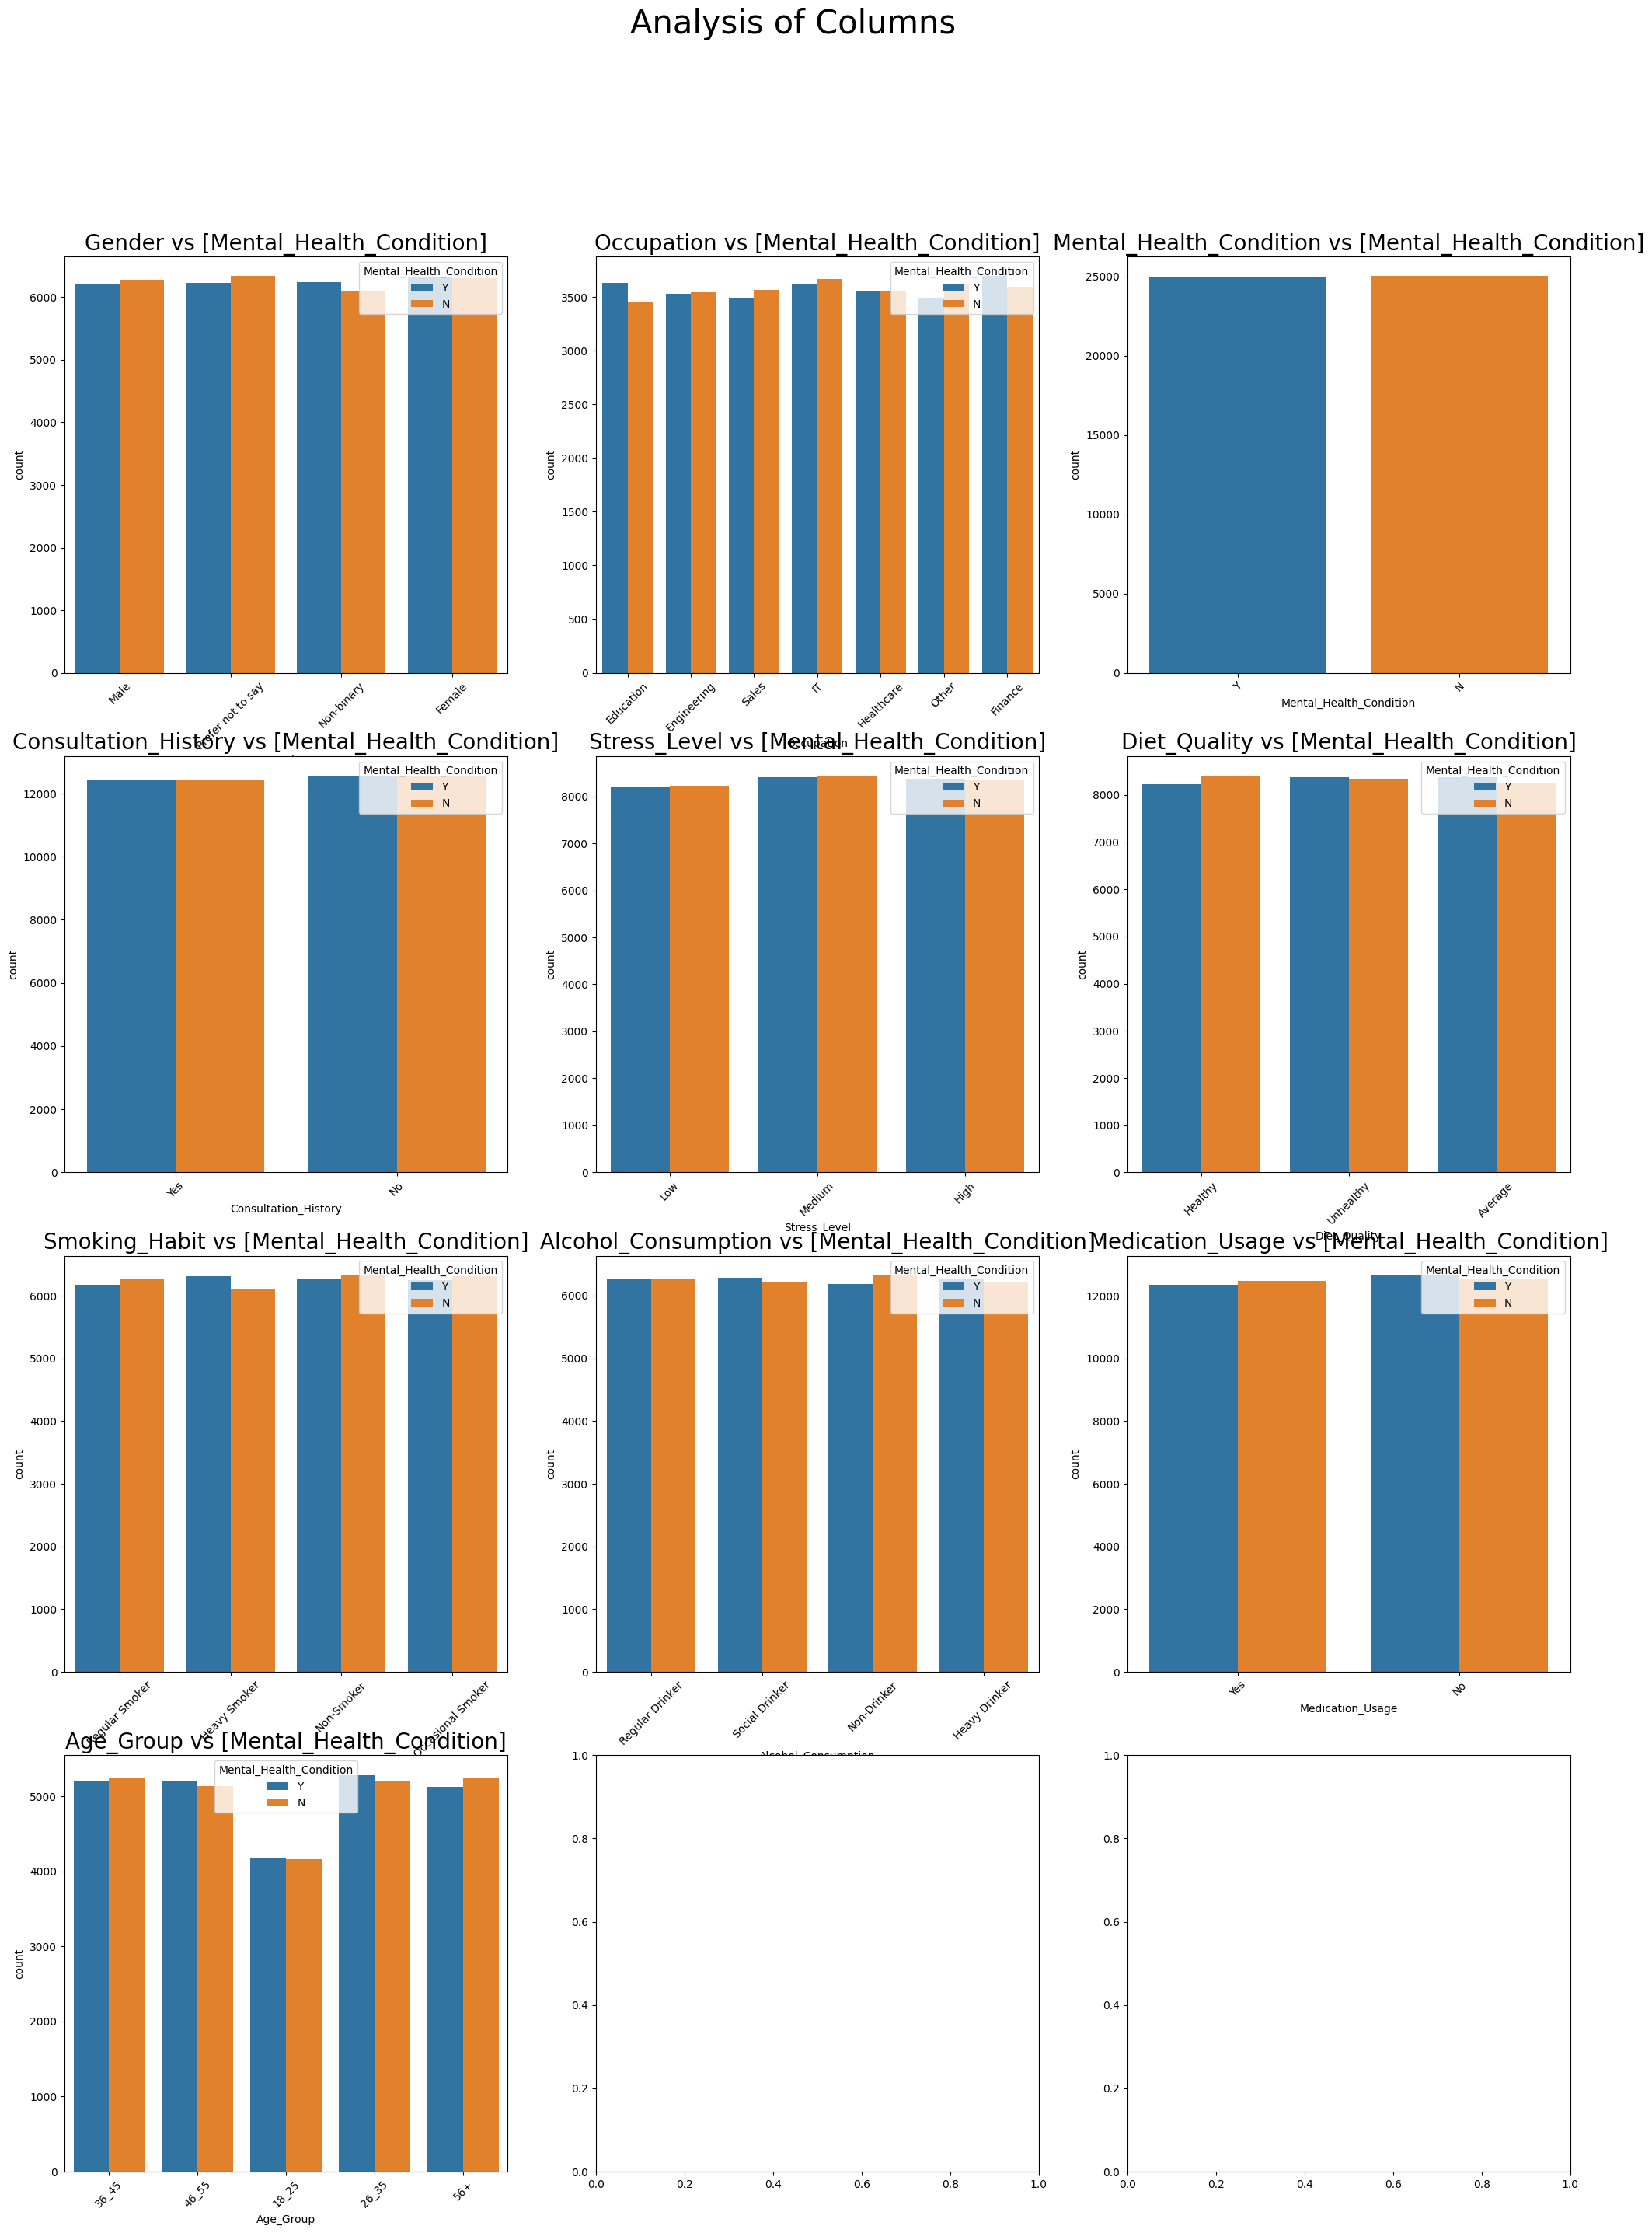

In [16]:
# Value counts analysis
# Non-numerical columns only
import math

n_cols = 3
n_plots = len(columns_to_analyze)

# Calculate the number of rows needed
n_rows = math.ceil(n_plots / n_cols)

# Create the subplots
fig, axs = plt.subplots(n_rows, n_cols, figsize=(25, 8 * n_rows))
fig.suptitle('Analysis of Columns', fontsize=30)

axs = axs.flatten()
    
# Loop through the columns and plot on each subplot
for i, column in enumerate(columns_to_analyze):
    sns.countplot(x = column, hue = LABEL, data = df, ax = axs[i])
    axs[i].set_title(f'{column} vs [{LABEL}]', fontsize=20)
    axs[i].tick_params(axis='x', rotation=45)


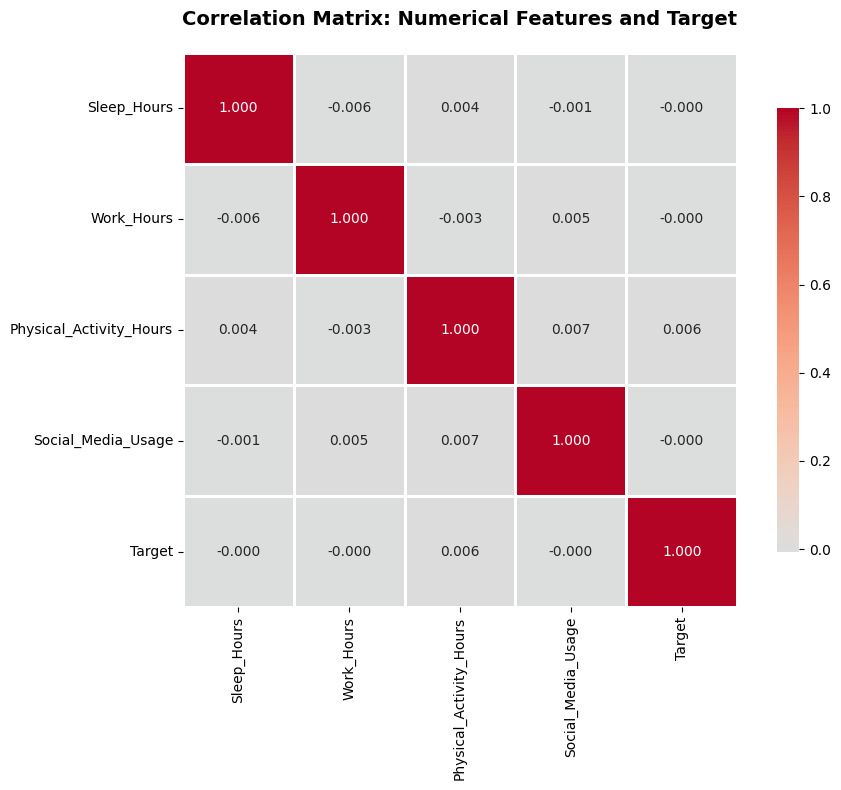

In [17]:
df_corr = df.copy()
df_corr['Target'] = df_corr['Mental_Health_Condition'].map({'Y': 1, 'N': 0})

numerical_features_with_target = ['Sleep_Hours', 'Work_Hours', 
                                  'Physical_Activity_Hours', 
                                  'Social_Media_Usage', 'Target']

corr_matrix = df_corr[numerical_features_with_target].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,           # Show correlation values
            fmt='.3f',            # 3 decimal places
            cmap='coolwarm',      # Color scheme
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            linewidths=1,         # Grid lines
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix: Numerical Features and Target', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [18]:
# Create pairplot with target as hue


# Subset data for faster plotting (optional if using full 50k rows)
# df_sample = df.sample(n=1500)
# #df_sample = df

# sns.pairplot(df_sample[numeric_cols.to_list() + ['Mental_Health_Condition']], 
#              hue='Mental_Health_Condition',
#              palette={'N': '#3498db', 'Y': '#e74c3c'},
#              diag_kind='kde',      # Kernel density on diagonal
#              plot_kws={'alpha': 0.6, 's': 30},  # Transparency and point size
#              height=2.5)

# plt.suptitle('Pairplot: Numerical Features by Mental Health Condition', 
#              y=1.02, fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

### Pairplot Interpretation:
- Scatter plots show considerable overlap between classes (Y and N)
- No clear linear separation visible in any single feature pair
- This supports the weak correlation findings from Step 3
- Suggests need for non-linear models (Random Forest, SVM) to capture complex interactions


C:\Users\danie\AppData\Local\Temp\ipykernel_36728\3092629697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mental_Health_Condition', y=col, data=df, ax=axes[i], palette='pastel')
C:\Users\danie\AppData\Local\Temp\ipykernel_36728\3092629697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mental_Health_Condition', y=col, data=df, ax=axes[i], palette='pastel')
C:\Users\danie\AppData\Local\Temp\ipykernel_36728\3092629697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mental_Health_Condition', y=col, data=df, ax=axes[i], p

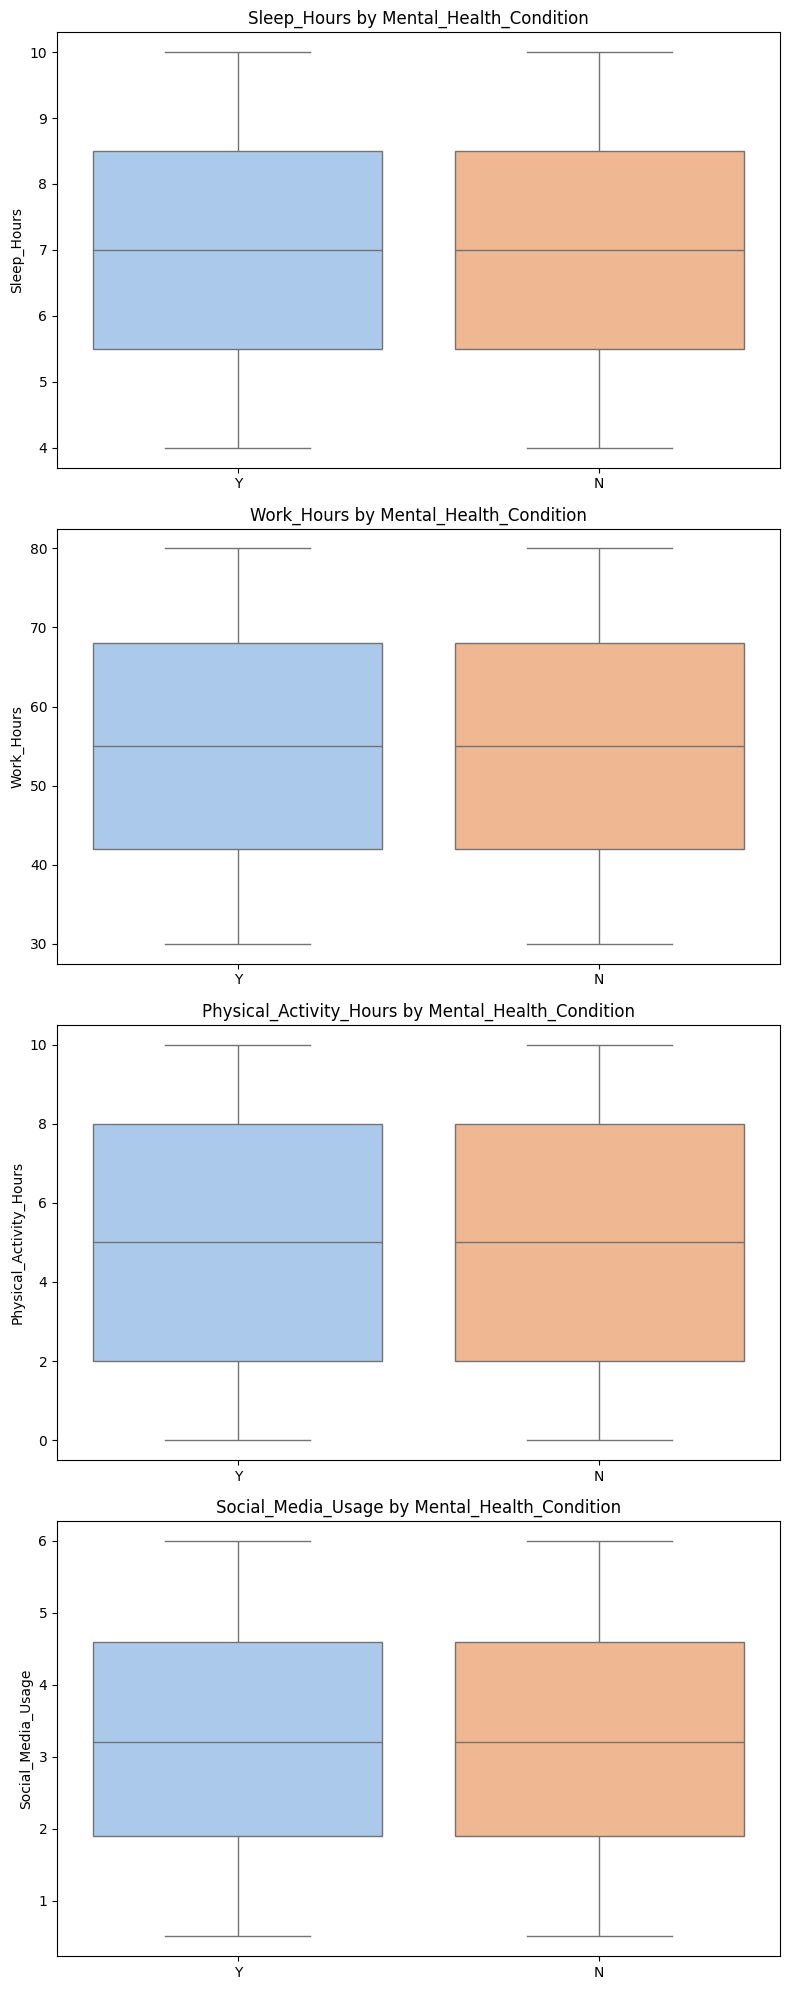

In [19]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, 5*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Mental_Health_Condition', y=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} by Mental_Health_Condition')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


In [20]:
print('Mean values of numerical columns grouped by Mental_Health_Condition:')
# Use only numeric columns to avoid attempting mean on object dtype columns
mean_values = df.groupby(LABEL)[numeric_cols].mean()
mean_values

Mean values of numerical columns grouped by Mental_Health_Condition:


,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage
Mental_Health_Condition,,,,
N,7.010731,55.067272,4.963724,3.243579
Y,7.009137,55.058447,5.000360,3.242741


array([[<Axes: title={'center': 'Sleep_Hours'}>,
        <Axes: title={'center': 'Work_Hours'}>],
       [<Axes: title={'center': 'Physical_Activity_Hours'}>,
        <Axes: title={'center': 'Social_Media_Usage'}>]], dtype=object)

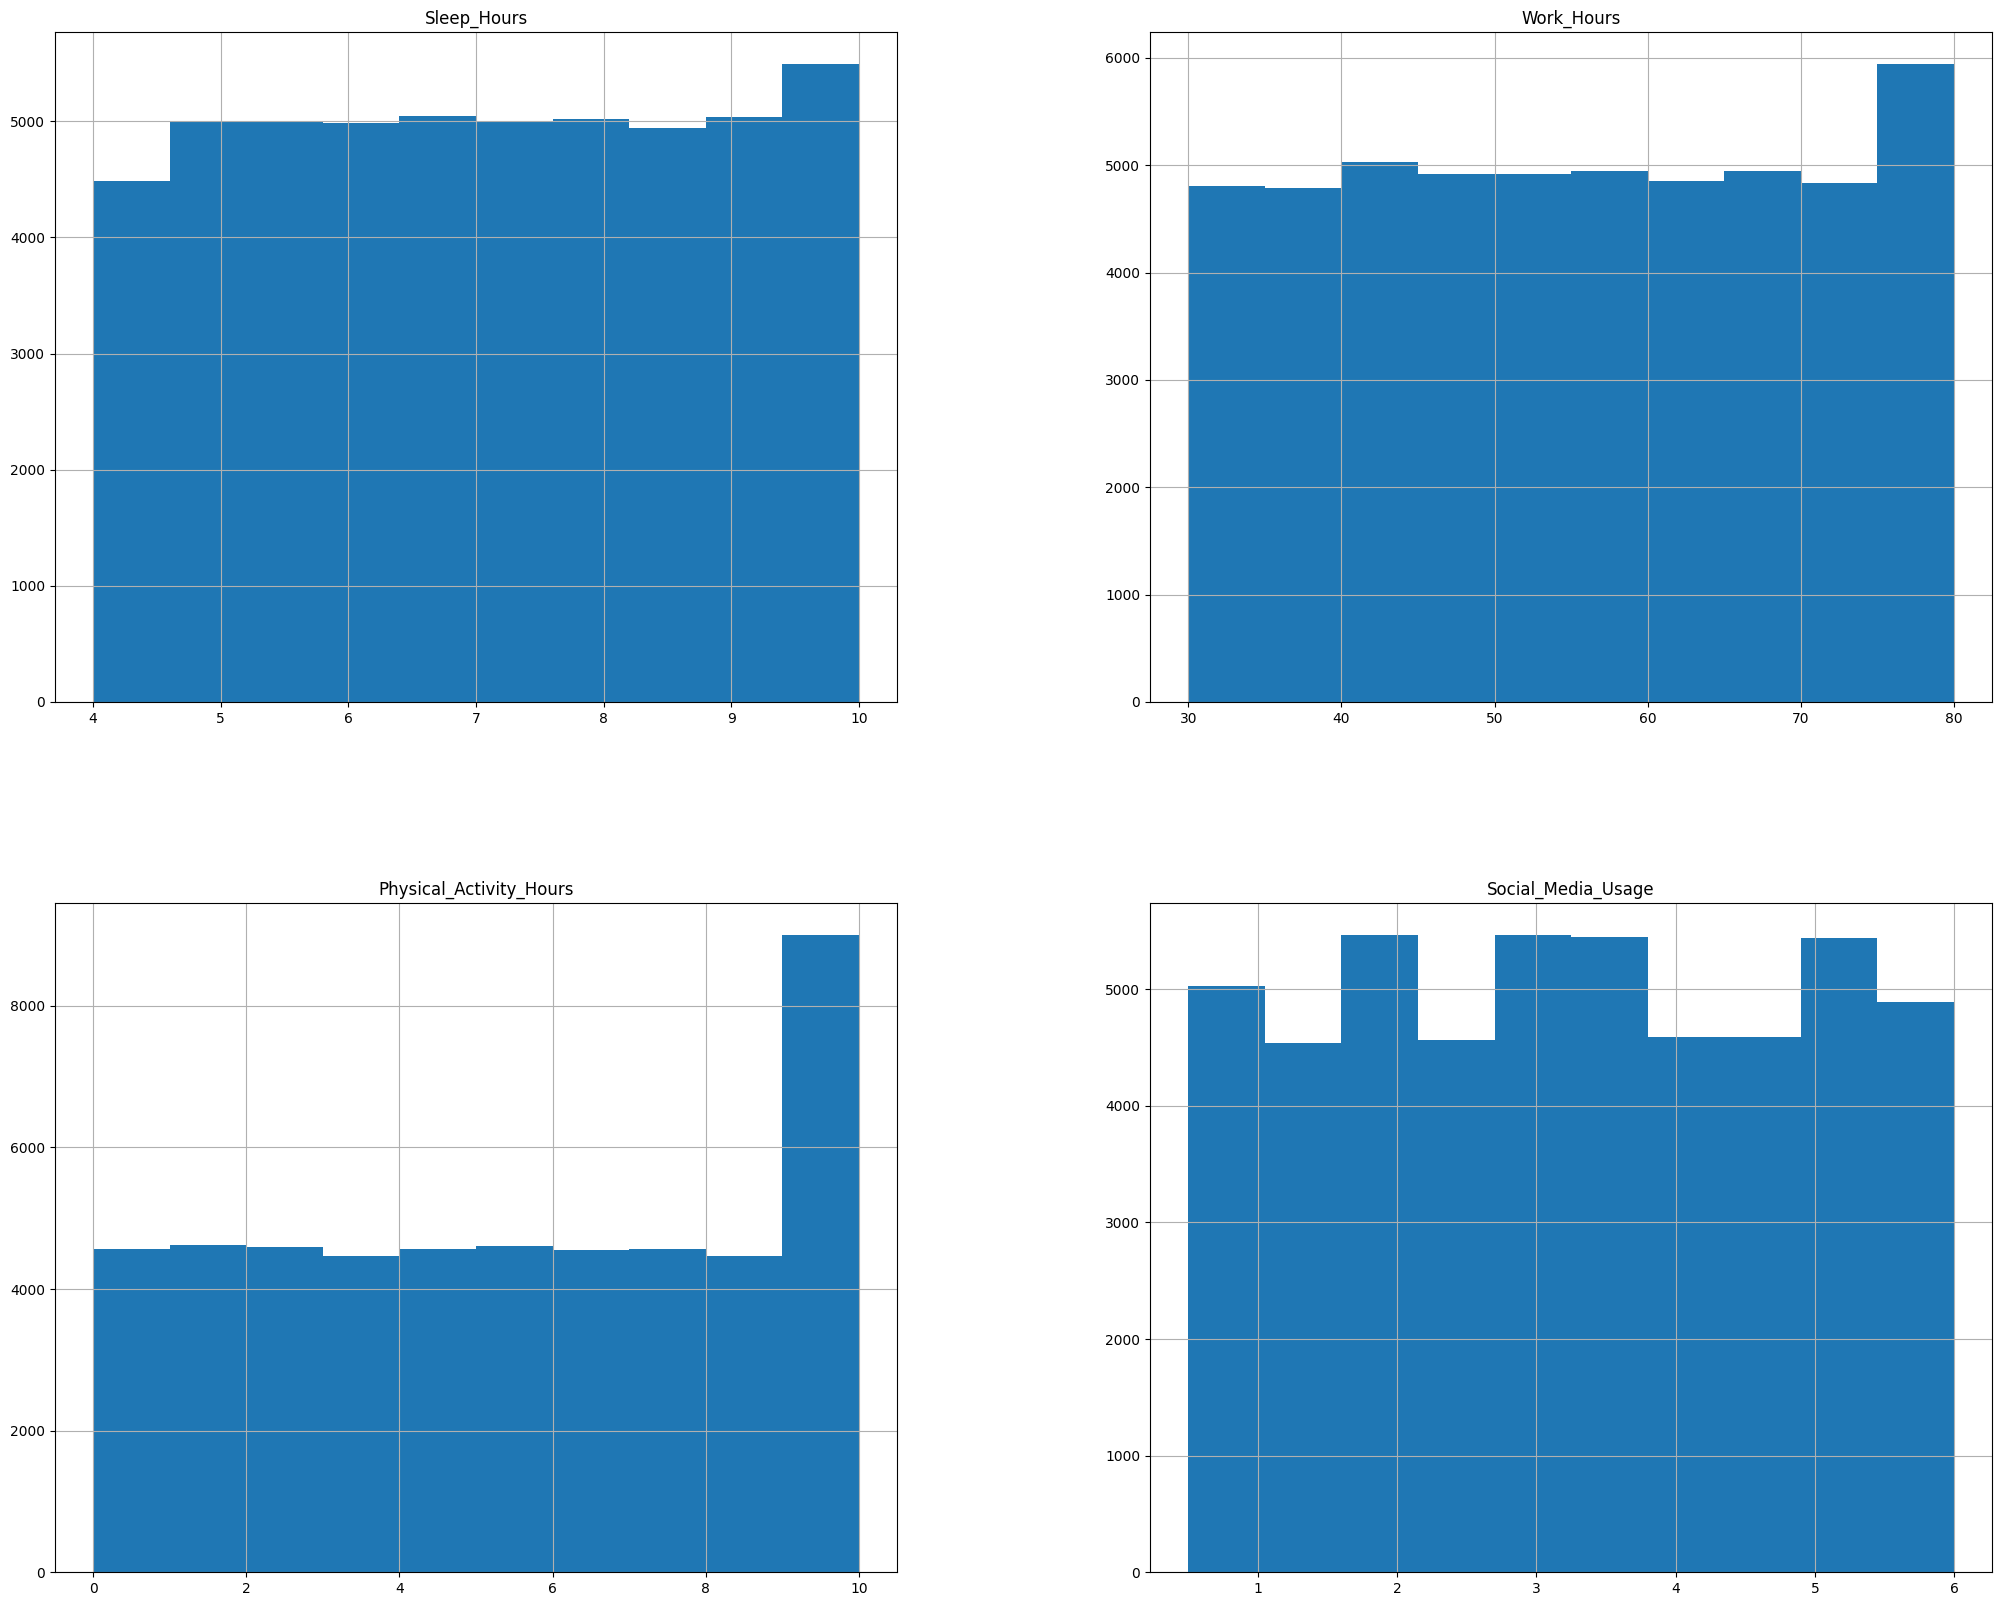

In [21]:
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols].hist(bins=10, figsize=(25, 20))

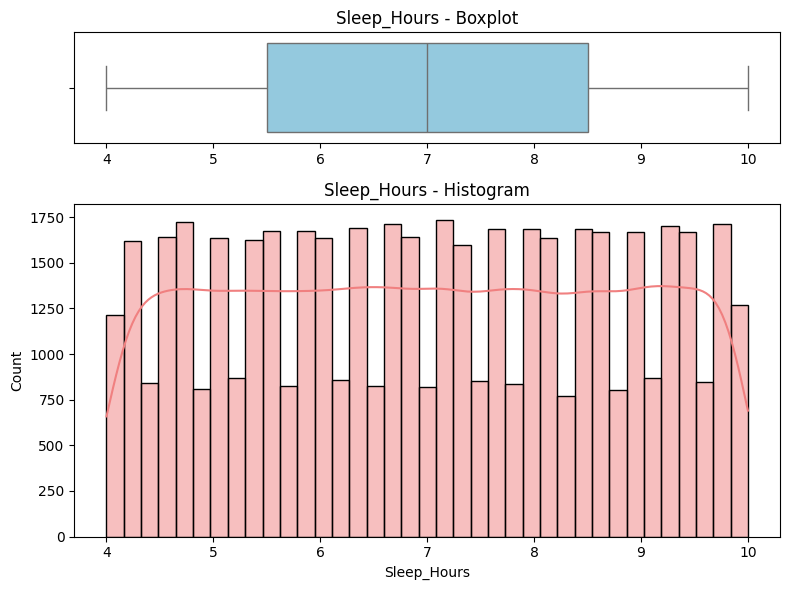

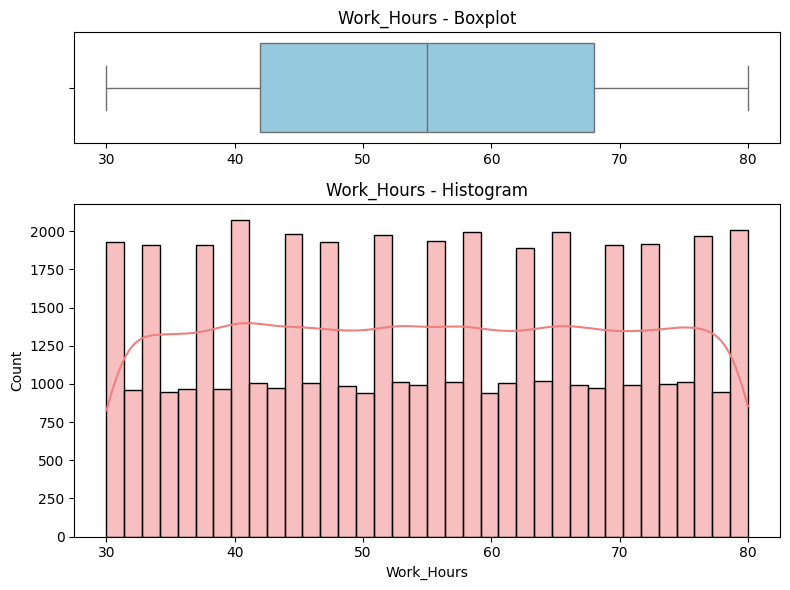

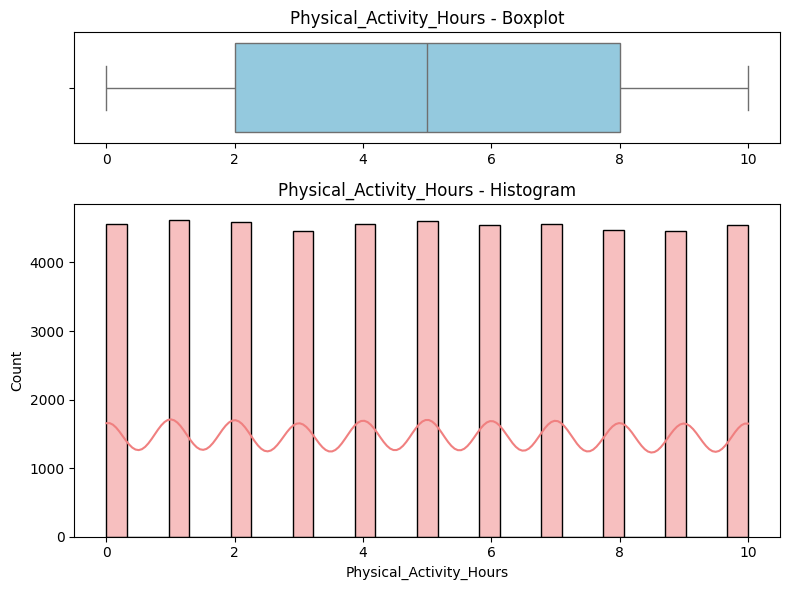

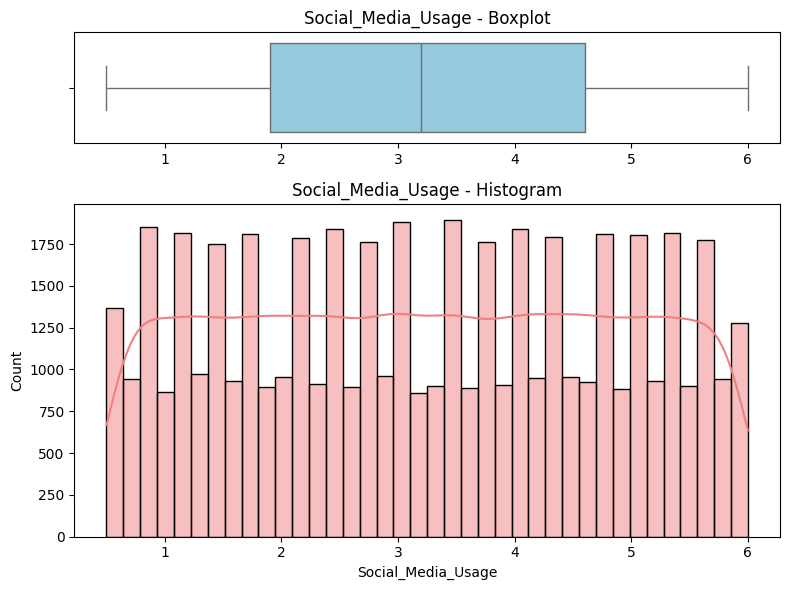

In [22]:
def hist_boxplot(df, col):
    """Plot histogram + boxplot for a single numeric column."""
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(8,6), 
                             gridspec_kw={'height_ratios': [1, 3]})
    
    # Boxplot (top)
    sns.boxplot(x=df[col], ax=axes[0], color='skyblue')
    axes[0].set(xlabel='', title=f'{col} - Boxplot')
    
    # Histogram (bottom)
    sns.histplot(df[col], kde=True, ax=axes[1], color='lightcoral', bins='fd')
    axes[1].set(title=f'{col} - Histogram')
    
    plt.tight_layout()
    plt.show()
for col in numeric_cols:
    hist_boxplot(df, col)

In [23]:
df.columns

Index(['Gender', 'Occupation', 'Mental_Health_Condition',
       'Consultation_History', 'Stress_Level', 'Sleep_Hours', 'Work_Hours',
       'Physical_Activity_Hours', 'Social_Media_Usage', 'Diet_Quality',
       'Smoking_Habit', 'Alcohol_Consumption', 'Medication_Usage',
       'Age_Group'],
      dtype='object')

## 5) Prepare data for input

Importing the needed libraries from sklearn in order to encode the non-numerical features for a cleaner approach!

In [24]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

nominal_features = ['Gender', 'Occupation', 'Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption']
binary_features = ['Consultation_History', 'Medication_Usage']
numerical_features = ['Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage']
ordinal_features = ['Stress_Level', 'Age_Group']

age_group_categories = list(splitter_dict.keys())

ordinal_categories = [
    ['Low', 'Medium', 'High'],       # categories for Stress_Level
    age_group_categories             # categories for Age_Group
]
age_group_categories


['18_25', '26_35', '36_45', '46_55', '56+']

In this section we map the n=binary features (to 1 and 0) so they work better in the training process.

In [25]:

# Mapping binary features to 0 and 1
for feature in binary_features:
    df[feature] = df[feature].map({'No': 0.0, 'Yes': 1.0})

# Mapping my label to 0 and 1 and preparing target variable y
y = df[LABEL].map({'N': 0.0, 'Y': 1.0})

# Prepare feature matrix X
feature_columns = nominal_features + binary_features + ordinal_features + numerical_features
X = df[feature_columns]
X


,Gender,Occupation,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Consultation_History,Medication_Usage,Stress_Level,Age_Group,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage
0,Male,Education,Healthy,Regular Smoker,Regular Drinker,1.0,1.0,Low,36_45,7.6,46,8,2.2
1,Male,Engineering,Unhealthy,Heavy Smoker,Social Drinker,0.0,0.0,Low,46_55,6.8,74,2,3.4
2,Prefer not to say,Sales,Healthy,Heavy Smoker,Social Drinker,1.0,0.0,Medium,18_25,7.1,77,9,5.9
3,Non-binary,Engineering,Average,Regular Smoker,Regular Drinker,0.0,0.0,Low,26_35,6.9,57,4,5.4
4,Male,IT,Unhealthy,Regular Smoker,Non-Drinker,1.0,1.0,High,56+,4.7,45,10,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Prefer not to say,Education,Unhealthy,Regular Smoker,Regular Drinker,1.0,1.0,High,36_45,8.4,45,4,1.3
49996,Female,Other,Healthy,Occasional Smoker,Social Drinker,1.0,1.0,High,18_25,9.9,68,6,5.1
49997,Prefer not to say,Education,Average,Non-Smoker,Heavy Drinker,0.0,0.0,Medium,26_35,5.2,61,6,2.1
49998,Prefer not to say,Other,Healthy,Occasional Smoker,Regular Drinker,0.0,1.0,High,26_35,8.2,59,0,1.9


Now, a pipeline definition is necessary in the sense it will help us to perform sequential encoding through every feature depending on its type.

For this purpose, we also classified the categorical features into ordinal and nominal in order to preserve the order of ordinal features and leverage speceialized encoding methods.

### Important Note:
A standard scaler was not specified in the guidelines for data preparation, but it was included after some research and getting to the conclusion that depending on the different algorithms that can be implemented for training purposes, numerical columns should be normalized and scaled to improve results.

In [26]:
# Using a pipeline to handle different feature types
preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), nominal_features),
        ('binary', 'passthrough', binary_features),
        ('ord', OrdinalEncoder(categories=ordinal_categories), ordinal_features)
    ])

Now, implementing the train_test_split module from sk.learn, we are going to split the data into training, validation and test datasets.

Proportions of the splitting are shown after execution

In [27]:
# First split: Train+Validation and Test sets
x_train, x_valtest, y_train, y_valtest = train_test_split(
    X, y, train_size=0.6, random_state=42, stratify=y)

x_val, x_test, y_val, y_test = train_test_split(
    x_valtest, y_valtest, train_size=0.5, random_state=42, stratify=y_valtest)

print(f"\nData split sizes:")
print(f"Training set: {x_train.shape[0]} samples ({x_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation set: {x_val.shape[0]} samples ({x_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test set: {x_test.shape[0]} samples ({x_test.shape[0]/len(df)*100:.1f}%)")


Data split sizes:
Training set: 30000 samples (60.0%)
Validation set: 10000 samples (20.0%)
Test set: 10000 samples (20.0%)


Fitting our transformer and perform fearure encoding:

In [28]:
# Fit the preprocessor on training data and transform all sets
X_train_processed = preprocessor1.fit_transform(x_train)
X_val_processed = preprocessor1.transform(x_val)
X_test_processed = preprocessor1.transform(x_test)

In [29]:
# Verify class distribution in each split
print(f"\nClass distribution verification:")
print(f"Training: {y_train.value_counts().to_dict()}")
print(f"Validation: {y_val.value_counts().to_dict()}")
print(f"Test: {y_test.value_counts().to_dict()}")


Class distribution verification:
Training: {0.0: 15002, 1.0: 14998}
Validation: {1.0: 5000, 0.0: 5000}
Test: {0.0: 5001, 1.0: 4999}


## 6) Save prepared data

In [30]:

feature_names = preprocessor1.get_feature_names_out(input_features=feature_columns)

# Transforming processed arrays back to DataFrames for easier handling
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_val_processed_df = pd.DataFrame(X_val_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

X_train_processed_df['ord__Stress_Level'].value_counts()


ord__Stress_Level
1.0    10185
2.0     9984
0.0     9831
Name: count, dtype: int64

In [31]:

X_train_processed_df.to_csv('data/X_train_processed.csv', index=False)
X_val_processed_df.to_csv('data/X_val_processed.csv', index=False)
X_test_processed_df.to_csv('data/X_test_processed.csv', index=False)

y_train.to_csv('data/y_train.csv', index=False)
y_val.to_csv('data/y_val.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)


# Training Phase
### A) Individual Model Development 

In this file, we will use the files that were generated so far in this file. The selected algorithm is the random forest, given that:

- Handles weak individual predictors by finding complex interactions​
- Works well with mixed data types (categorical + numerical)​
- Built-in resistance to overfitting through ensemble averaging​
- Provides feature importance for interpretability

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Default random forest: Initial one
rf_baseline = RandomForestClassifier(
    n_estimators=100,        # 100 trees
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

In [34]:
rf_baseline.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
# Evaluate on validation set (not test yet!)
y_val_pred = rf_baseline.predict(X_val_processed)
y_val_proba = rf_baseline.predict_proba(X_val_processed)[:, 1]

print("Baseline Random Forest Performance:")
print(classification_report(y_val, y_val_pred))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

Baseline Random Forest Performance:
              precision    recall  f1-score   support

         0.0       0.50      0.52      0.51      5000
         1.0       0.50      0.48      0.49      5000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000

ROC-AUC: 0.4982


## Overfitting or Underfitting?

We can compare both our training performance vs our validation performance to verify there is no undergitting or overfitting:

In [39]:
# Training performance
y_train_pred = rf_baseline.predict(X_train_processed)
train_accuracy = (y_train_pred == y_train).mean()

# Validation performance
val_accuracy = (y_val_pred == y_val).mean()

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Difference: {train_accuracy - val_accuracy:.4f}")

# Diagnosis:
if train_accuracy - val_accuracy > 0.10:
    print("Likely OVERFITTING - model memorizing training data")
elif val_accuracy < 0.55:
    print("Likely UNDERFITTING - model too simple")
else:
    print("✓ Model appears balanced")


Training Accuracy: 1.0000
Validation Accuracy: 0.4985
Difference: 0.5015
Likely OVERFITTING - model memorizing training data


## Conclusion
So our model seems to be overfitted in the sense accuracy is perfect for our training phase, but does really badly on validation, and the gap is considerably high.

So, knowing this, we are going to use Grid Search Algorithm (Testing every single possible combination of hyperparameters for our model using cross validation to evaluate metrics evenly and reducing risk of overfitting to a single validation set).

In [40]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],           # Number of trees
    'max_depth': [10, 20, 30, None],           # Tree depth
    'min_samples_split': [2, 5, 10],           # Min samples to split
    'min_samples_leaf': [1, 2, 4],             # Min samples in leaf
    'max_features': ['sqrt', 'log2']           # Features per split
}

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,                              # 5-fold cross-validation
    scoring='roc_auc',                 # Optimize for ROC-AUC
    n_jobs=-1,
    verbose=2                          # Show progress
)

# Fit on training data (this will take time)
print("Starting hyperparameter tuning... This may take several minutes.")
grid_search.fit(X_train_processed, y_train)

# Best model
best_rf = grid_search.best_estimator_
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation ROC-AUC: {grid_search.best_score_:.4f}")


Starting hyperparameter tuning... This may take several minutes.
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation ROC-AUC: 0.5005


## Testing Tuned Model

In [41]:
# Predict on validation set
y_val_pred_tuned = best_rf.predict(X_val_processed)
y_val_proba_tuned = best_rf.predict_proba(X_val_processed)[:, 1]

# Comprehensive evaluation

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_tuned, 
                          target_names=['No Condition', 'Has Condition']))

print(f"\nROC-AUC Score: {roc_auc_score(y_val, y_val_proba_tuned):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred_tuned)
print(cm)
print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

# Re-check for overfitting
y_train_pred_tuned = best_rf.predict(X_train_processed)
train_acc_tuned = (y_train_pred_tuned == y_train).mean()
val_acc_tuned = (y_val_pred_tuned == y_val).mean()

print(f"\nTraining Accuracy: {train_acc_tuned:.4f}")
print(f"Validation Accuracy: {val_acc_tuned:.4f}")
print(f"Gap: {train_acc_tuned - val_acc_tuned:.4f}")


Classification Report:
               precision    recall  f1-score   support

 No Condition       0.50      0.50      0.50      5000
Has Condition       0.50      0.50      0.50      5000

     accuracy                           0.50     10000
    macro avg       0.50      0.50      0.50     10000
 weighted avg       0.50      0.50      0.50     10000


ROC-AUC Score: 0.4932

Confusion Matrix:
[[2486 2514]
 [2519 2481]]
True Negatives: 2486, False Positives: 2514
False Negatives: 2519, True Positives: 2481

Training Accuracy: 1.0000
Validation Accuracy: 0.4967
Gap: 0.5033


In [ ]:
def performance_checker(model, x_train, x_val):
    # Additional Training phase
    model.fit(x_train, y_train)
    # Predict on validation set
    y_val_pred = model.predict(x_val)
    y_val_proba = model.predict_proba(x_val)[:, 1]

    # Comprehensive evaluation

    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred, 
                            target_names=['No Condition', 'Has Condition']))

    print(f"\nROC-AUC Score: {roc_auc_score(y_val, y_val_proba):.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

    # Re-check for overfitting
    y_train_pred = model.predict(X_train_processed)
    train_acc = (y_train_pred == y_train).mean()
    val_acc = (y_val_pred == y_val).mean()

    print(f"\nTraining Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Gap: {train_acc - val_acc:.4f}")


TOP 15 MOST IMPORTANT FEATURES
                                    Feature  Importance
                           num__Sleep_Hours    0.149080
                    num__Social_Media_Usage    0.146984
                            num__Work_Hours    0.143997
               num__Physical_Activity_Hours    0.098946
                             ord__Age_Group    0.066542
                          ord__Stress_Level    0.044488
                   binary__Medication_Usage    0.028118
               binary__Consultation_History    0.027451
             onehot__Diet_Quality_Unhealthy    0.022374
               onehot__Diet_Quality_Healthy    0.021322
       onehot__Smoking_Habit_Regular Smoker    0.019978
    onehot__Smoking_Habit_Occasional Smoker    0.019884
           onehot__Smoking_Habit_Non-Smoker    0.018758
onehot__Alcohol_Consumption_Regular Drinker    0.018364
    onehot__Alcohol_Consumption_Non-Drinker    0.018247


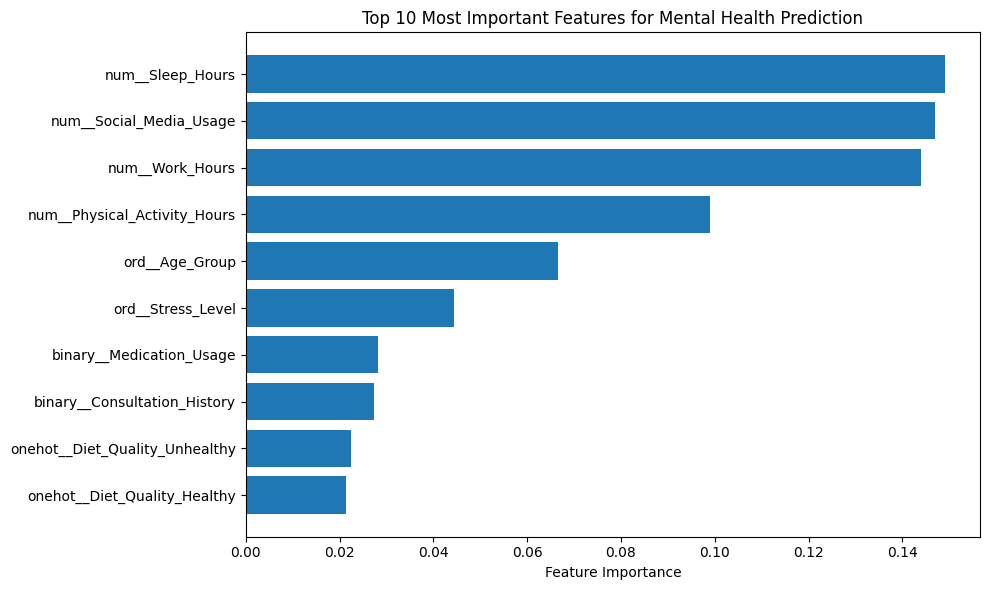

In [42]:
# Get feature importances
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display top 15 features
print("\n" + "="*60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance_df.head(15).to_string(index=False))

# Visualize top 10
plt.figure(figsize=(10, 6))
top_10 = feature_importance_df.head(10)
plt.barh(top_10['Feature'], top_10['Importance'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Mental Health Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
rf_conservative_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,              # Limit depth
    min_samples_split=10,      # Need 10+ samples to split
    min_samples_leaf=5,        # Need 5+ samples per leaf
    max_features='sqrt',
    random_state=42
)



In [53]:
performance_checker(rf_conservative_2, X_train_processed, X_val_processed)


Classification Report:
               precision    recall  f1-score   support

 No Condition       0.50      0.49      0.49      5000
Has Condition       0.50      0.50      0.50      5000

     accuracy                           0.50     10000
    macro avg       0.50      0.50      0.50     10000
 weighted avg       0.50      0.50      0.50     10000


ROC-AUC Score: 0.4934

Confusion Matrix:
[[2456 2544]
 [2490 2510]]
True Negatives: 2456, False Positives: 2544
False Negatives: 2490, True Positives: 2510

Training Accuracy: 0.9953
Validation Accuracy: 0.4966
Gap: 0.4987


In [56]:
from sklearn.svm import SVC

# SVM with RBF kernel
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,  # Enable probability estimates
    random_state=42
)



In [57]:
performance_checker(svm_model, X_train_processed, X_val_processed)


Classification Report:
               precision    recall  f1-score   support

 No Condition       0.50      0.51      0.50      5000
Has Condition       0.50      0.49      0.49      5000

     accuracy                           0.50     10000
    macro avg       0.50      0.50      0.50     10000
 weighted avg       0.50      0.50      0.50     10000


ROC-AUC Score: 0.5000

Confusion Matrix:
[[2529 2471]
 [2561 2439]]
True Negatives: 2529, False Positives: 2471
False Negatives: 2561, True Positives: 2439

Training Accuracy: 0.5931
Validation Accuracy: 0.4968
Gap: 0.0963
